In [1]:
!pip install -q qiskit qiskit-aer matplotlib numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.6 MB/s eta 0:00:00


In [ ]:
!pip install -q pylatexenc

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
simulator = AerSimulator()

print("Aer Simulator ready.")

Aer Simulator ready.


In [4]:
from qiskit import QuantumCircuit

def constant_zero_oracle():
    """
    Oracle for f(x) = 0.
    The target qubit remains unchanged.
    """

    oracle = QuantumCircuit(2)

    # No operation required because f(x) = 0

    return oracle

In [6]:
def deutsch_algorithm(oracle):

    qc = QuantumCircuit(2, 1)

    # Initial state |0>|1>
    qc.x(1)

    # Create superposition
    qc.h(0)
    qc.h(1)

    # Oracle
    qc.compose(oracle, inplace=True)

    # Hadamard on input/control qubit
    qc.h(0)

    # Measure first qubit
    qc.measure(0, 0)

    return qc

In [7]:
oracle = constant_zero_oracle()

qc_easy = deutsch_algorithm(oracle)

print(qc_easy.draw(output="text"))

     ┌───┐┌───┐┌─┐
q_0: ┤ H ├┤ H ├┤M├
     ├───┤├───┤└╥┘
q_1: ┤ X ├┤ H ├─╫─
     └───┘└───┘ ║ 
c: 1/═══════════╩═
                0 


In [8]:
compiled_circuit = transpile(qc_easy, simulator)

result = simulator.run(
    compiled_circuit,
    shots=1024
).result()

counts = result.get_counts()

print("Measurement Results:")
print(counts)

Measurement Results:
{'0': 1024}


In [9]:
def balanced_oracle():
    """
    Oracle for f(x) = x.
    Implemented using CNOT.
    """

    oracle = QuantumCircuit(2)

    # CNOT:
    # qubit 0 = input/control
    # qubit 1 = target
    oracle.cx(0, 1)

    return oracle

In [10]:
oracle = balanced_oracle()

qc_medium = deutsch_algorithm(oracle)

print(qc_medium.draw(output="text"))

     ┌───┐          ┌───┐┌─┐
q_0: ┤ H ├───────■──┤ H ├┤M├
     ├───┤┌───┐┌─┴─┐└───┘└╥┘
q_1: ┤ X ├┤ H ├┤ X ├──────╫─
     └───┘└───┘└───┘      ║ 
c: 1/═════════════════════╩═
                          0 


In [11]:
compiled_circuit = transpile(qc_medium, simulator)

result = simulator.run(
    compiled_circuit,
    shots=1024
).result()

counts = result.get_counts()

print("Measurement Results:")
print(counts)

Measurement Results:
{'1': 1024}


In [12]:
def create_oracle(function_type):

    oracle = QuantumCircuit(2)

    if function_type == "constant_0":

        # f(x) = 0
        pass


    elif function_type == "constant_1":

        # f(x) = 1
        oracle.x(1)


    elif function_type == "balanced_x":

        # f(x) = x
        oracle.cx(0, 1)


    elif function_type == "balanced_not_x":

        # f(x) = 1 - x
        oracle.x(0)
        oracle.cx(0, 1)
        oracle.x(0)


    else:
        raise ValueError(
            "Invalid function type. Choose: "
            "constant_0, constant_1, balanced_x, balanced_not_x"
        )

    return oracle

In [13]:
def run_deutsch(function_type, shots=1024):

    # Create oracle
    oracle = create_oracle(function_type)

    # Create Deutsch circuit
    qc = QuantumCircuit(2, 1)

    # Initial state |0>|1>
    qc.x(1)

    # Hadamard gates
    qc.h(0)
    qc.h(1)

    # Apply oracle
    qc.compose(oracle, inplace=True)

    # Final Hadamard
    qc.h(0)

    # Measurement
    qc.measure(0, 0)

    # Execute
    compiled = transpile(qc, simulator)

    result = simulator.run(
        compiled,
        shots=shots
    ).result()

    counts = result.get_counts()

    # Determine result
    measured_bit = max(counts, key=counts.get)

    if measured_bit == '0':
        classification = "CONSTANT"
    else:
        classification = "BALANCED"

    return qc, counts, classification

In [14]:
functions = [
    "constant_0",
    "constant_1",
    "balanced_x",
    "balanced_not_x"
]

for function in functions:

    qc, counts, classification = run_deutsch(function)

    print("=" * 60)
    print("Function:", function)
    print("Measurement:", counts)
    print("Deutsch Result:", classification)

Function: constant_0
Measurement: {'0': 1024}
Deutsch Result: CONSTANT
Function: constant_1
Measurement: {'0': 1024}
Deutsch Result: CONSTANT
Function: balanced_x
Measurement: {'1': 1024}
Deutsch Result: BALANCED
Function: balanced_not_x
Measurement: {'1': 1024}
Deutsch Result: BALANCED


In [15]:
for function in functions:

    qc, counts, classification = run_deutsch(function)

    print("\n")
    print("=" * 60)
    print("Function:", function)
    print("Classification:", classification)
    print("=" * 60)

    print(qc.draw(output="text"))



Function: constant_0
Classification: CONSTANT
     ┌───┐┌───┐┌─┐
q_0: ┤ H ├┤ H ├┤M├
     ├───┤├───┤└╥┘
q_1: ┤ X ├┤ H ├─╫─
     └───┘└───┘ ║ 
c: 1/═══════════╩═
                0 


Function: constant_1
Classification: CONSTANT
     ┌───┐┌───┐     ┌─┐
q_0: ┤ H ├┤ H ├─────┤M├
     ├───┤├───┤┌───┐└╥┘
q_1: ┤ X ├┤ H ├┤ X ├─╫─
     └───┘└───┘└───┘ ║ 
c: 1/════════════════╩═
                     0 


Function: balanced_x
Classification: BALANCED
     ┌───┐          ┌───┐┌─┐
q_0: ┤ H ├───────■──┤ H ├┤M├
     ├───┤┌───┐┌─┴─┐└───┘└╥┘
q_1: ┤ X ├┤ H ├┤ X ├──────╫─
     └───┘└───┘└───┘      ║ 
c: 1/═════════════════════╩═
                          0 


Function: balanced_not_x
Classification: BALANCED
     ┌───┐┌───┐     ┌───┐┌───┐┌─┐
q_0: ┤ H ├┤ X ├──■──┤ X ├┤ H ├┤M├
     ├───┤├───┤┌─┴─┐└───┘└───┘└╥┘
q_1: ┤ X ├┤ H ├┤ X ├───────────╫─
     └───┘└───┘└───┘           ║ 
c: 1/══════════════════════════╩═
                               0 


In [16]:
def classification_oracle():

    oracle = QuantumCircuit(2)

    # Example classifier:
    # f(0) = 0
    # f(1) = 1

    oracle.cx(0, 1)

    return oracle

In [17]:
qc_classification = deutsch_algorithm(
    classification_oracle()
)

print(qc_classification.draw(output="text"))

compiled = transpile(
    qc_classification,
    simulator
)

result = simulator.run(
    compiled,
    shots=1024
).result()

counts = result.get_counts()

print("\nClassification Oracle Result:")
print(counts)

     ┌───┐          ┌───┐┌─┐
q_0: ┤ H ├───────■──┤ H ├┤M├
     ├───┤┌───┐┌─┴─┐└───┘└╥┘
q_1: ┤ X ├┤ H ├┤ X ├──────╫─
     └───┘└───┘└───┘      ║ 
c: 1/═════════════════════╩═
                          0 

Classification Oracle Result:
{'1': 1024}


In [18]:
qc_phase = QuantumCircuit(2, 1)

# Prepare |0>|1>
qc_phase.x(1)

# Superposition
qc_phase.h(0)
qc_phase.h(1)

# Balanced oracle
qc_phase.cx(0, 1)

# Final Hadamard
qc_phase.h(0)

# Measure
qc_phase.measure(0, 0)

print(qc_phase.draw(output="text"))

     ┌───┐          ┌───┐┌─┐
q_0: ┤ H ├───────■──┤ H ├┤M├
     ├───┤┌───┐┌─┴─┐└───┘└╥┘
q_1: ┤ X ├┤ H ├┤ X ├──────╫─
     └───┘└───┘└───┘      ║ 
c: 1/═════════════════════╩═
                          0 


In [19]:
qc_phase = QuantumCircuit(2, 1)

# Prepare |0>|1>
qc_phase.x(1)

# Superposition
qc_phase.h(0)
qc_phase.h(1)

# Balanced oracle
qc_phase.cx(0, 1)

# Final Hadamard
qc_phase.h(0)

# Measure
qc_phase.measure(0, 0)

print(qc_phase.draw(output="text"))

     ┌───┐          ┌───┐┌─┐
q_0: ┤ H ├───────■──┤ H ├┤M├
     ├───┤┌───┐┌─┴─┐└───┘└╥┘
q_1: ┤ X ├┤ H ├┤ X ├──────╫─
     └───┘└───┘└───┘      ║ 
c: 1/═════════════════════╩═
                          0 


In [20]:
def imperfect_hadamard(qc, qubit, error):

    # Ideal Hadamard corresponds approximately to Ry(pi/2)
    qc.ry(np.pi / 2 + error, qubit)

In [21]:
def deutsch_with_error(error, shots=1000):

    qc = QuantumCircuit(2, 1)

    # Initial state |0>|1>
    qc.x(1)

    # Imperfect Hadamard gates
    imperfect_hadamard(qc, 0, error)
    imperfect_hadamard(qc, 1, error)

    # Balanced oracle f(x)=x
    qc.cx(0, 1)

    # Imperfect final Hadamard
    imperfect_hadamard(qc, 0, error)

    # Measurement
    qc.measure(0, 0)

    compiled = transpile(qc, simulator)

    result = simulator.run(
        compiled,
        shots=shots
    ).result()

    counts = result.get_counts()

    return counts

In [22]:
errors = [
    0,
    0.01,
    0.05,
    0.10,
    0.20,
    0.30,
    0.50
]

for error in errors:

    counts = deutsch_with_error(
        error,
        shots=1000
    )

    correct = counts.get('1', 0)
    reliability = correct / 1000

    print(
        f"Error = {error:.2f} rad | "
        f"Counts = {counts} | "
        f"Reliability = {reliability:.3f}"
    )

Error = 0.00 rad | Counts = {'0': 1000} | Reliability = 0.000
Error = 0.01 rad | Counts = {'0': 1000} | Reliability = 0.000
Error = 0.05 rad | Counts = {'0': 1000} | Reliability = 0.000
Error = 0.10 rad | Counts = {'0': 1000} | Reliability = 0.000
Error = 0.20 rad | Counts = {'1': 11, '0': 989} | Reliability = 0.011
Error = 0.30 rad | Counts = {'1': 24, '0': 976} | Reliability = 0.024
Error = 0.50 rad | Counts = {'1': 45, '0': 955} | Reliability = 0.045


In [23]:
errors = np.linspace(0, 0.5, 11)

reliabilities = []

shots = 2000

for error in errors:

    counts = deutsch_with_error(
        error,
        shots=shots
    )

    correct_results = counts.get('1', 0)

    reliability = correct_results / shots

    reliabilities.append(reliability)

print("Error values:")
print(errors)

print("\nReliability values:")
print(reliabilities)

Error values:
[0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5 ]

Reliability values:
[0.0, 0.0005, 0.002, 0.0045, 0.01, 0.014, 0.028, 0.0225, 0.0315, 0.0445, 0.0455]


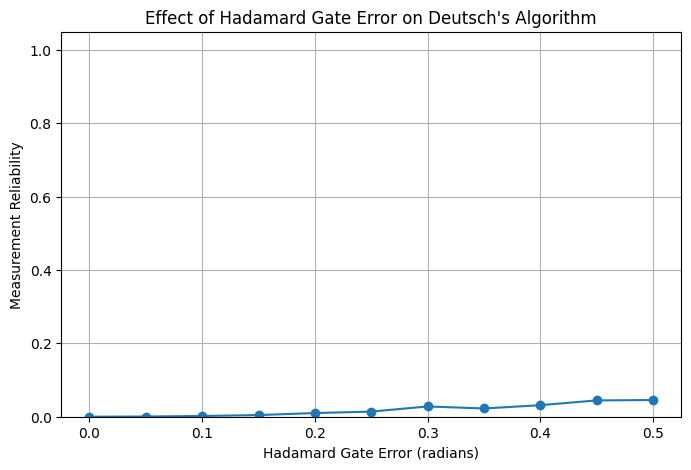

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    errors,
    reliabilities,
    marker='o'
)

plt.xlabel("Hadamard Gate Error (radians)")
plt.ylabel("Measurement Reliability")
plt.title("Effect of Hadamard Gate Error on Deutsch's Algorithm")

plt.ylim(0, 1.05)
plt.grid(True)

plt.show()

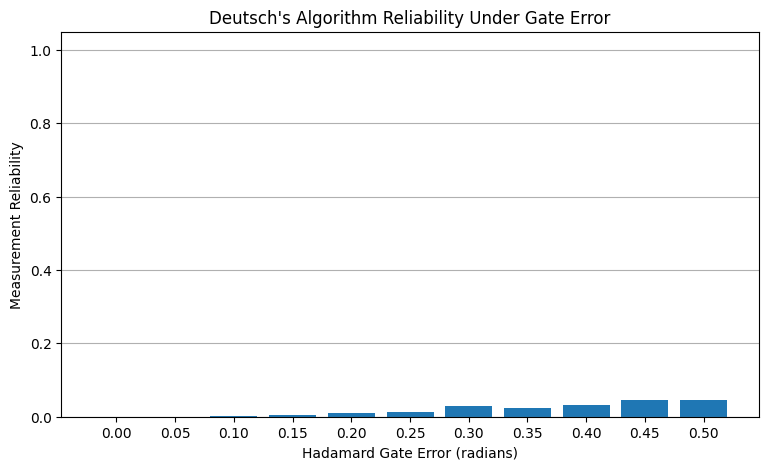

In [25]:
plt.figure(figsize=(9, 5))

plt.bar(
    [f"{e:.2f}" for e in errors],
    reliabilities
)

plt.xlabel("Hadamard Gate Error (radians)")
plt.ylabel("Measurement Reliability")
plt.title("Deutsch's Algorithm Reliability Under Gate Error")

plt.ylim(0, 1.05)
plt.grid(axis='y')

plt.show()

In [26]:
print("Hadamard Error Analysis")
print("-" * 45)
print(f"{'Error (rad)':<15}{'Reliability':<15}")
print("-" * 45)

for error, reliability in zip(errors, reliabilities):

    print(
        f"{error:<15.2f}"
        f"{reliability:<15.3f}"
    )

Hadamard Error Analysis
---------------------------------------------
Error (rad)    Reliability    
---------------------------------------------
0.00           0.000          
0.05           0.001          
0.10           0.002          
0.15           0.004          
0.20           0.010          
0.25           0.014          
0.30           0.028          
0.35           0.022          
0.40           0.032          
0.45           0.044          
0.50           0.045          


In [27]:
function_details = {
    "constant_0": "f(x) = 0",
    "constant_1": "f(x) = 1",
    "balanced_x": "f(x) = x",
    "balanced_not_x": "f(x) = 1 - x"
}

for function, equation in function_details.items():

    qc, counts, classification = run_deutsch(function)

    print("=" * 70)
    print("Function:", equation)
    print("Type:", classification)
    print("Measurement:", counts)

Function: f(x) = 0
Type: CONSTANT
Measurement: {'0': 1024}
Function: f(x) = 1
Type: CONSTANT
Measurement: {'0': 1024}
Function: f(x) = x
Type: BALANCED
Measurement: {'1': 1024}
Function: f(x) = 1 - x
Type: BALANCED
Measurement: {'1': 1024}


In [28]:

for function, equation in function_details.items():

    oracle = create_oracle(function)

    print("\n" + "=" * 70)
    print(equation)
    print("=" * 70)

    print("Oracle:")
    print(oracle.draw(output="text"))


f(x) = 0
Oracle:
     
q_0: 
     
q_1: 
     

f(x) = 1
Oracle:
          
q_0: ─────
     ┌───┐
q_1: ┤ X ├
     └───┘

f(x) = x
Oracle:
          
q_0: ──■──
     ┌─┴─┐
q_1: ┤ X ├
     └───┘

f(x) = 1 - x
Oracle:
     ┌───┐     ┌───┐
q_0: ┤ X ├──■──┤ X ├
     └───┘┌─┴─┐└───┘
q_1: ─────┤ X ├─────
          └───┘     


In [29]:
def demonstrate_deutsch(function_type):

    qc, counts, classification = run_deutsch(
        function_type,
        shots=1024
    )

    print("\n" + "=" * 70)
    print("DEUTSCH'S ALGORITHM")
    print("=" * 70)

    print("Function:", function_details[function_type])
    print("Measurement:", counts)
    print("Final Classification:", classification)

    print("\nQuantum Circuit:")
    print(qc.draw(output="text"))

    return qc, counts, classification